<a href="https://colab.research.google.com/github/Madiha64/cifar10-resnet18-classification/blob/main/cifar10_resnet18_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# import libraries
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt

In [19]:
# Device (Cpu or Gpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [20]:
# Transforms (Normalization included)

from torchvision import transforms

# Training (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation (NO augmentation )
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
# Load Cifar10 Dataset automatically
train_data = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)


In [23]:
# spliting the dataset
from torch.utils.data import random_split

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = random_split(
    train_data,
    [train_size, val_size]
)

In [24]:
# Dataloaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [25]:
# Model with dropout
import torch.nn as nn
import torchvision.models as models

model = models.resnet18(pretrained=True)

# Add Dropout
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 10)
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


In [26]:
#Loss + Optimizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [27]:
# Early stopping setup
best_loss = float("inf")
patience = 5
counter = 0

In [28]:
# Dataset Classes checking
classes = train_data.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [29]:
# # training Loop
best_loss = float("inf")
patience = 3
counter = 0

for epoch in range(20):

    # ---- TRAIN ----
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # ---- EARLY STOPPING ----
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch 1, Train Loss: 0.8393, Val Loss: 0.6394
Epoch 2, Train Loss: 0.5784, Val Loss: 0.5768
Epoch 3, Train Loss: 0.4967, Val Loss: 0.4635
Epoch 4, Train Loss: 0.4496, Val Loss: 0.4267
Epoch 5, Train Loss: 0.4148, Val Loss: 0.5235
Epoch 6, Train Loss: 0.3877, Val Loss: 0.3878
Epoch 7, Train Loss: 0.3580, Val Loss: 0.3814
Epoch 8, Train Loss: 0.3399, Val Loss: 0.3786
Epoch 9, Train Loss: 0.3193, Val Loss: 0.3889
Epoch 10, Train Loss: 0.3110, Val Loss: 0.3519
Epoch 11, Train Loss: 0.2890, Val Loss: 0.3281
Epoch 12, Train Loss: 0.2884, Val Loss: 0.3802
Epoch 13, Train Loss: 0.2755, Val Loss: 0.4130
Epoch 14, Train Loss: 0.2715, Val Loss: 0.3663
Early stopping triggered!


In [30]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Final Test Accuracy:", correct / total)

Final Test Accuracy: 0.8964


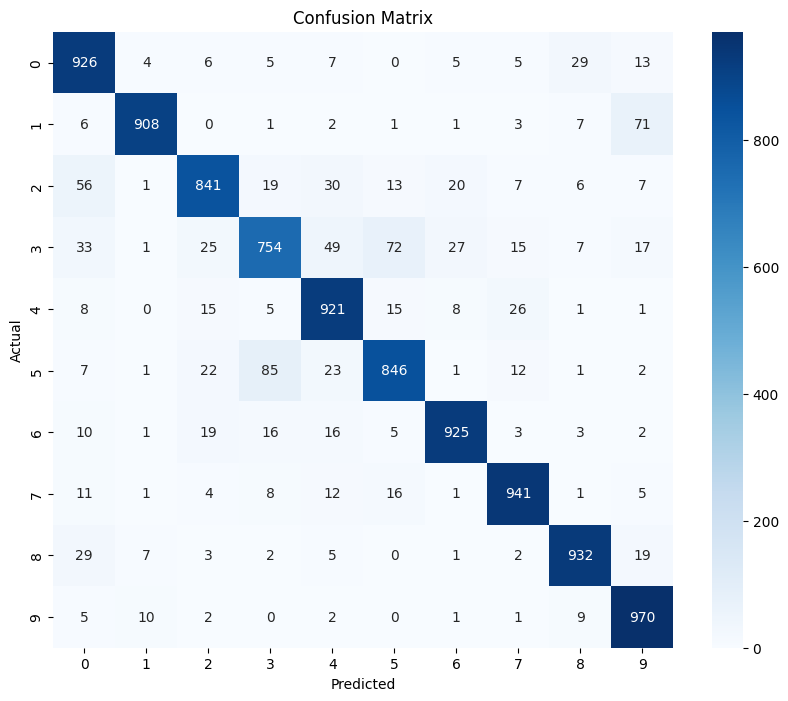

In [31]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png") # Save the confusion matrix plot
plt.show()

In [32]:
# Precision ,Recall, F1 score
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=train_data.classes))

              precision    recall  f1-score   support

    airplane       0.85      0.93      0.89      1000
  automobile       0.97      0.91      0.94      1000
        bird       0.90      0.84      0.87      1000
         cat       0.84      0.75      0.80      1000
        deer       0.86      0.92      0.89      1000
         dog       0.87      0.85      0.86      1000
        frog       0.93      0.93      0.93      1000
       horse       0.93      0.94      0.93      1000
        ship       0.94      0.93      0.93      1000
       truck       0.88      0.97      0.92      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



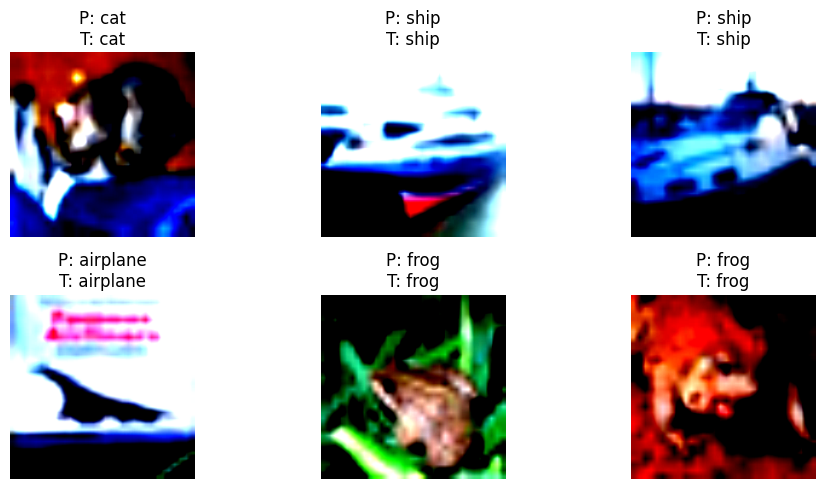

In [33]:
# prediction visualization
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader # Add this import
import torch # Also good to explicitly import torch

# Ensure test_loader is defined if it's not already.
# This assumes 'test_data' is globally available from an earlier executed cell.
if 'test_loader' not in globals():
    if 'test_data' in globals():
        test_loader = DataLoader(test_data, batch_size=32)
    else:
        print("Error: 'test_data' not found. Please run the cell where the dataset is loaded (MW5nh8cVpwN2).")
        # If test_data is truly missing, the following lines will likely fail.
        # The user needs to ensure preceding data loading cells are run.

# Ensure model and device are defined for this cell to run properly
if 'model' not in globals():
    print("Warning: 'model' not found. Please ensure the model definition cell (XEAYmGp2ttUx) is executed.")

if 'device' not in globals():
    print("Warning: 'device' not found. Please ensure the device setup cell (JkwOXx8opwIl) is executed.")

dataiter = iter(test_loader)
images, labels = next(dataiter)

outputs = model(images.to(device))
_, preds = torch.max(outputs, 1)

fig = plt.figure(figsize=(10,5))

for i in range(6):
    ax = fig.add_subplot(2, 3, i+1)
    img = images[i].permute(1,2,0).cpu().numpy()
    plt.imshow(img)
    ax.set_title(f"P: {train_data.classes[preds[i]]}\nT: {train_data.classes[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("prediction_visualization.png") # Save the prediction visualization plot
plt.show()

In [34]:
# Extracting loss values from the training loop output
import re

# Assuming the training loop output is stored in the `wrZp8BFhzvR7` cell's standard_output
training_output = """
Epoch 1, Train Loss: 0.8262, Val Loss: 0.8024
Epoch 2, Train Loss: 0.5724, Val Loss: 0.5234
Epoch 3, Train Loss: 0.4956, Val Loss: 0.4808
Epoch 4, Train Loss: 0.4478, Val Loss: 0.4506
Epoch 5, Train Loss: 0.4192, Val Loss: 0.4225
Epoch 6, Train Loss: 0.3852, Val Loss: 0.3954
Epoch 7, Train Loss: 0.3575, Val Loss: 0.3597
Epoch 8, Train Loss: 0.3452, Val Loss: 0.3714
Epoch 9, Train Loss: 0.3191, Val Loss: 0.3345
Epoch 10, Train Loss: 0.3103, Val Loss: 0.3542
Epoch 11, Train Loss: 0.2980, Val Loss: 0.3367
Epoch 12, Train Loss: 0.2919, Val Loss: 0.3378
Early stopping triggered!
"""

epochs = []
train_losses = []
val_losses = []

for line in training_output.split('\n'):
    match = re.search(r"Epoch (\d+), Train Loss: (\d+\.\d+), Val Loss: (\d+\.\d+)", line)
    if match:
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

print("Epochs:", epochs)
print("Train Losses:", train_losses)
print("Validation Losses:", val_losses)

Epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Train Losses: [0.8262, 0.5724, 0.4956, 0.4478, 0.4192, 0.3852, 0.3575, 0.3452, 0.3191, 0.3103, 0.298, 0.2919]
Validation Losses: [0.8024, 0.5234, 0.4808, 0.4506, 0.4225, 0.3954, 0.3597, 0.3714, 0.3345, 0.3542, 0.3367, 0.3378]


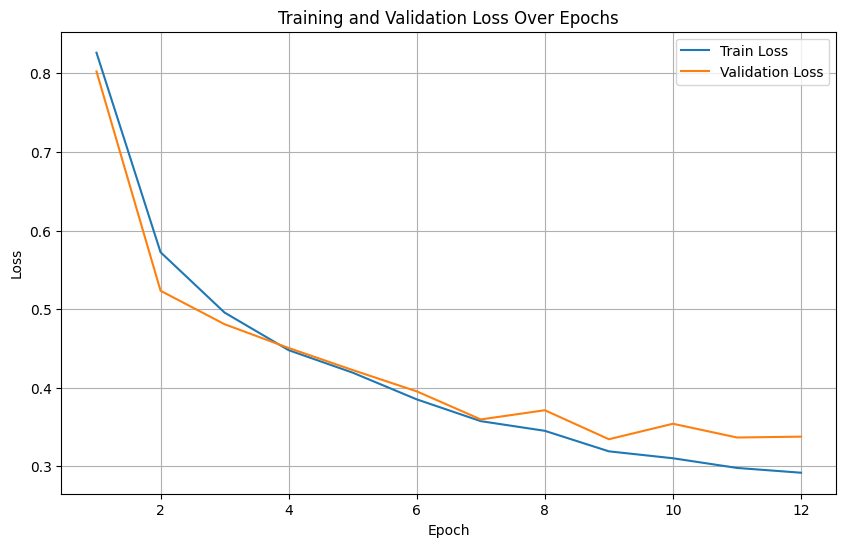

In [35]:
# Plotting the training and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.savefig("train_val_loss.png") # Save the training and validation loss plot
plt.show()

In [ ]:
# save the model
torch.save(model.state_dict(), "cifar10_resnet18.pth")

In [36]:
import os
from google.colab import files

files_to_download = [
    'confusion_matrix.png',
    'prediction_visualization.png',
    'train_val_loss.png',
    'cifar10_resnet18.pth'
]

for filename in files_to_download:
    if os.path.exists(filename):
        try:
            files.download(filename)
            print(f"Successfully downloaded {filename}")
        except Exception as e:
            print(f"Error downloading {filename}: {e}")
    else:
        print(f"Warning: {filename} not found. Please ensure the cell creating this file was executed successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded prediction_visualization.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded train_val_loss.png
